# Phase 3: Biologically Inspired Hidden Perturbations (2nd Hidden Layer)

A single model trained on the clean SHD dataset is evaluated under each
perturbation applied to the **2nd hidden layer output** (train-once / eval-all
protocol — no retraining per perturbation level).

Two model variants are compared:
- **SGD-delay** (solid, filled circles): SNN with learnable axonal delays.
- **SGD** (dashed, × markers): baseline SNN without delays.

Three dataset variants: **Whole** (blue), **Part** (green), **Norm** (red).

The sweeps are grouped into three figures by what each manipulation does to the
2nd-hidden code:

1. **Relocation + jitter** — both scramble spike timing at (near-)fixed spike count;
   relocation is unbounded within the layer's support, jitter is local.
2. **Shift + deletion** — shift moves each neuron's train as a block (intra-neuron
   ISI preserved); deletion removes drive outright, lowering the spike count.
3. **Time reversal** — count, rate, ISI, and coincidences all preserved; only the
   causal direction of time is flipped.

## 3A-D: Relocation, Jitter, Shift and Deletion (2nd Hidden Layer)

All four sweeps are applied to the **2nd hidden layer** output under the same
train-once / eval-all protocol: for each `(dataset, delay-mode)` the clean-trained
2nd-layer checkpoint is evaluated across the sweep, so the panels are directly
comparable to one another.

- **Per-Spike Random Relocation** — a fraction $f$ of each 2nd-hidden neuron's spikes
  is removed and re-inserted at randomly chosen empty time bins inside the layer's
  temporal support, so the per-neuron spike count is preserved exactly and only
  timing is destroyed. Sweep: $f$ = 0.0 → 1.0. These are the SHD results from the
  Phase 2 realistic experiments (`code/realistic/shd/`), read in place so the two
  notebooks never diverge.
- **Per-Spike Jitter** — independent Gaussian noise (σ ms) added to each spike time.
  Sweep: σ = 0 → 25 ms.
- **Per-Neuron Shift** — the same Gaussian offset applied to **all spikes from a given
  2nd-hidden neuron**, preserving intra-neuron ISI while disrupting cross-neuron
  timing. Sweep: σ = 0 → 25 ms.
- **Spike Deletion** — each 2nd-hidden spike independently dropped with probability
  $p_d$, reducing total spike count while preserving the timing of survivors.
  Sweep: $p_d$ = 0.0 → 0.8.

Within each figure the two panels share the y-axis and the legend.

In [1]:
import json
import pathlib
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import matplotlib as mpl

mpl.rcParams.update({
    "font.family": "sans-serif",
    "font.size": 11,
    "axes.labelsize": 13,
    "axes.titlesize": 14,
    "legend.fontsize": 9.5,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "figure.dpi": 150,
})

# Notebook lives in result_visualization/FWP_2ndLayer_results/perturbation/;
# sweep results are read in place from exp_fixed_weight_perturbation/code/.
CODE_PERTURBATION_DIR = pathlib.Path("../../../code/perturbation")
CODE_REALISTIC_DIR = pathlib.Path("../../../code/realistic")

VARIANTS = ("Whole", "Part", "Norm")
COLORS = {"Whole": "#1f77b4", "Part": "#2ca02c", "Norm": "#d62728"}


def load_sweep(path: pathlib.Path) -> tuple[list[float], np.ndarray, np.ndarray]:
    """Return (sigma_values, means_pct, stds_pct) from a sweep results JSON."""
    with open(path) as fh:
        raw = json.load(fh)
    sigmas = sorted(int(k) for k in raw)
    means = np.array([raw[str(s)]["mean"] for s in sigmas]) * 100
    stds = np.array([raw[str(s)]["std"] for s in sigmas]) * 100
    return sigmas, means, stds

In [2]:
RELOCATION_LOG = CODE_REALISTIC_DIR / "shd/log"
JITTER_LOG = CODE_PERTURBATION_DIR / "jitter/log"
SHIFT_LOG = CODE_PERTURBATION_DIR / "shift/log"
DELETION_LOG = CODE_PERTURBATION_DIR / "deletion/log"


def load_sweep_float(path: pathlib.Path) -> tuple[list[float], np.ndarray, np.ndarray]:
    """Like load_sweep but treats result-keys as floats (for p_d / f values)."""
    with open(path) as fh:
        raw = json.load(fh)
    items = sorted(((float(k), k) for k in raw), key=lambda p: p[0])
    xs = [p[0] for p in items]
    means = np.array([raw[k]["mean"] for _, k in items]) * 100
    stds = np.array([raw[k]["std"] for _, k in items]) * 100
    return xs, means, stds


def load_group(
    log_dir: pathlib.Path,
    filename_template: str,
    loader,
) -> dict[tuple[str, bool], tuple[list, np.ndarray, np.ndarray]]:
    """Load one perturbation's six sweeps, keyed by (dataset_variant, uses_delay).

    Args:
        log_dir: Directory holding the sweep result JSONs.
        filename_template: Template with ``{variant}`` and ``{mode}`` fields.
        loader: Either ``load_sweep`` (integer keys) or ``load_sweep_float``.

    Returns:
        Mapping from (variant, uses_delay) to (x_values, means_pct, stds_pct).
    """
    sweeps = {}
    for variant in VARIANTS:
        for uses_delay in (True, False):
            filename = filename_template.format(
                variant=variant.lower(),
                mode="delay" if uses_delay else "nodelay",
            )
            sweeps[(variant, uses_delay)] = loader(log_dir / filename)
    return sweeps


def draw_sweep_panel(
    ax: plt.Axes,
    sweeps: dict,
    title: str,
    xlabel: str,
    xlim: tuple[float, float],
) -> None:
    """Draw one perturbation sweep panel onto *ax*.

    SGD-delay curves are solid with filled circles, SGD (no delay) curves are
    dashed with x markers; colour encodes the dataset variant.
    """
    for uses_delay, style, markersize, alpha in [
        (True, "o-", 5, 0.12),
        (False, "x--", 6, 0.08),
    ]:
        for variant in VARIANTS:
            xs, means, stds = sweeps[(variant, uses_delay)]
            ax.plot(xs, means, style, color=COLORS[variant],
                    markersize=markersize, linewidth=1.8)
            ax.fill_between(xs, means - stds, means + stds,
                            color=COLORS[variant], alpha=alpha)

    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_xlim(*xlim)
    ax.grid(True, linestyle=":", linewidth=0.7, alpha=0.7)


def build_legend_handles(solid_label: str, dashed_label: str) -> list[mlines.Line2D]:
    """Build the shared legend: two line styles in column 1, variants in column 2.

    Matplotlib fills legend columns top-to-bottom, so a blank third entry keeps
    the line styles and the dataset variants in separate columns when the legend
    is drawn with ``ncol=2``.

    Args:
        solid_label: Label for the solid / filled-circle style.
        dashed_label: Label for the dashed / x-marker style.

    Returns:
        Handles ready to pass to ``ax.legend(handles=...)``.
    """
    blank = mlines.Line2D([], [], linestyle="none", marker="none", label="")
    return [
        mlines.Line2D([], [], color="black", marker="o", linestyle="-",
                      markersize=5, linewidth=1.8, label=solid_label),
        mlines.Line2D([], [], color="black", marker="x", linestyle="--",
                      markersize=6, linewidth=1.8, label=dashed_label),
        blank,
    ] + [
        mlines.Line2D([], [], color=COLORS[variant], linewidth=2.5, label=variant)
        for variant in VARIANTS
    ]


def draw_paired_figure(
    panels: list[tuple[dict, str, str, tuple[float, float]]],
    legend_panel: int = 1,
) -> plt.Figure:
    """Draw a two-panel sweep figure with panel labels and one shared legend.

    Args:
        panels: Two ``(sweeps, title, xlabel, xlim)`` tuples, left then right.
        legend_panel: Index of the panel that carries the shared legend.

    Returns:
        The completed figure.
    """
    fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), sharey=True)

    for ax, panel_label, (sweeps, title, xlabel, xlim) in zip(axes, "ab", panels):
        draw_sweep_panel(ax, sweeps, title, xlabel, xlim)
        ax.text(-0.06, 1.04, f"({panel_label})", transform=ax.transAxes,
                fontsize=14, fontweight="bold")

    axes[0].set_ylabel("Test Accuracy (%)")
    axes[0].set_ylim(0, None)
    axes[legend_panel].legend(handles=build_legend_handles("SGD-delay", "SGD"),
                              loc="upper right", framealpha=0.9, ncol=2)

    fig.tight_layout()
    return fig


# ---------- Load sweep results (2nd-layer, eval-only) ----------
# Relocation reuses the Phase 2 realistic SHD logs (see code/realistic/shd/).
relocation_sweeps = load_group(
    RELOCATION_LOG,
    "shd_2ndLayer_{variant}_{mode}_hidden_perturbation_results.json",
    load_sweep_float)
jitter_sweeps = load_group(
    JITTER_LOG,
    "jitter_2ndLayer_{variant}_{mode}_evalOnly_jitter_sweep_results.json",
    load_sweep)
shift_sweeps = load_group(
    SHIFT_LOG,
    "shift_2ndLayer_{variant}_{mode}_evalOnly_shift_sweep_results.json",
    load_sweep)
deletion_sweeps = load_group(
    DELETION_LOG,
    "deletion_2ndLayer_{variant}_{mode}_evalOnly_deletion_sweep_results.json",
    load_sweep_float)

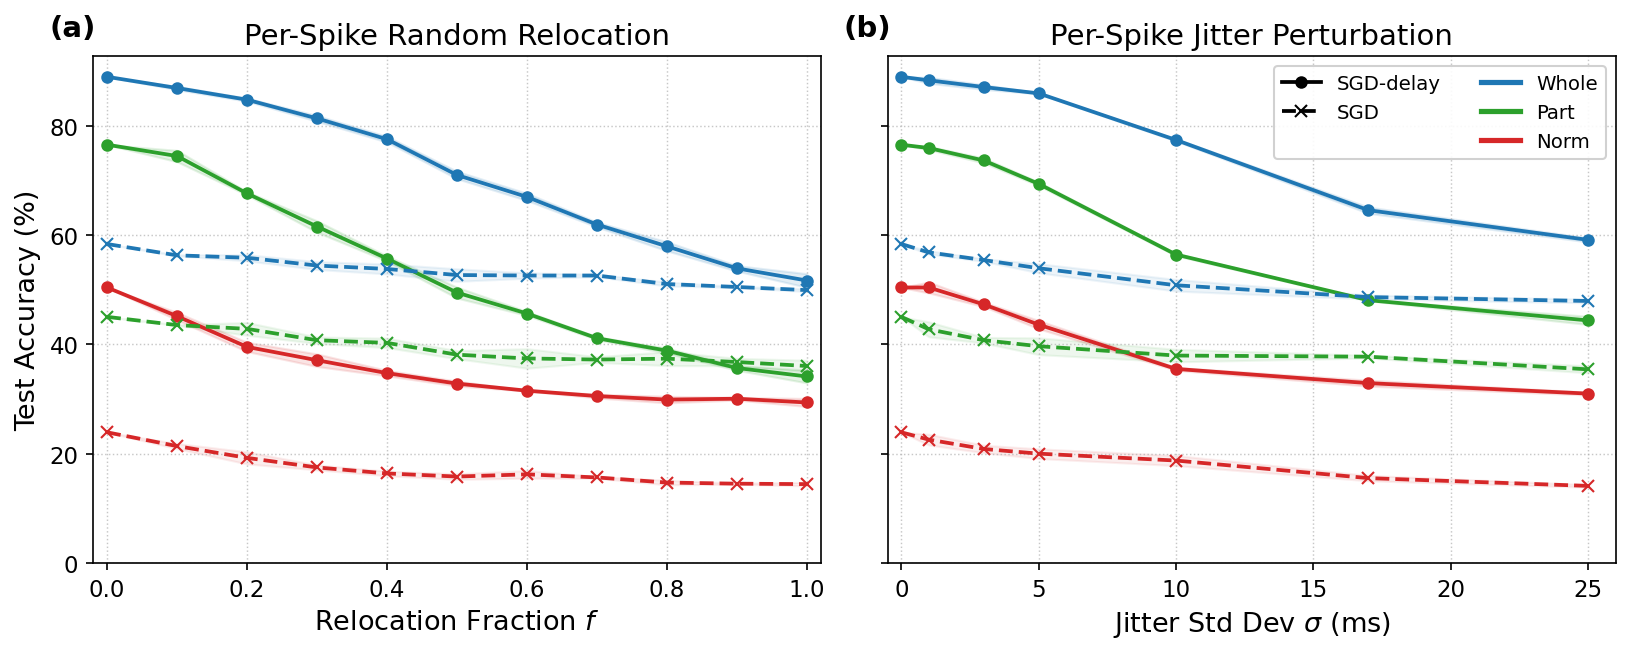

In [3]:
# ---------- Figure 1: relocation | jitter ----------
# Both destroy spike timing at (near-)fixed spike count.
fig = draw_paired_figure([
    (relocation_sweeps, "Per-Spike Random Relocation",
     r"Relocation Fraction $f$", (-0.02, 1.02)),
    (jitter_sweeps, "Per-Spike Jitter Perturbation",
     r"Jitter Std Dev $\sigma$ (ms)", (-0.5, 26)),
])
#fig.savefig("relocation_jitter_2ndLayer_results.png", dpi=150, bbox_inches="tight")
plt.show()

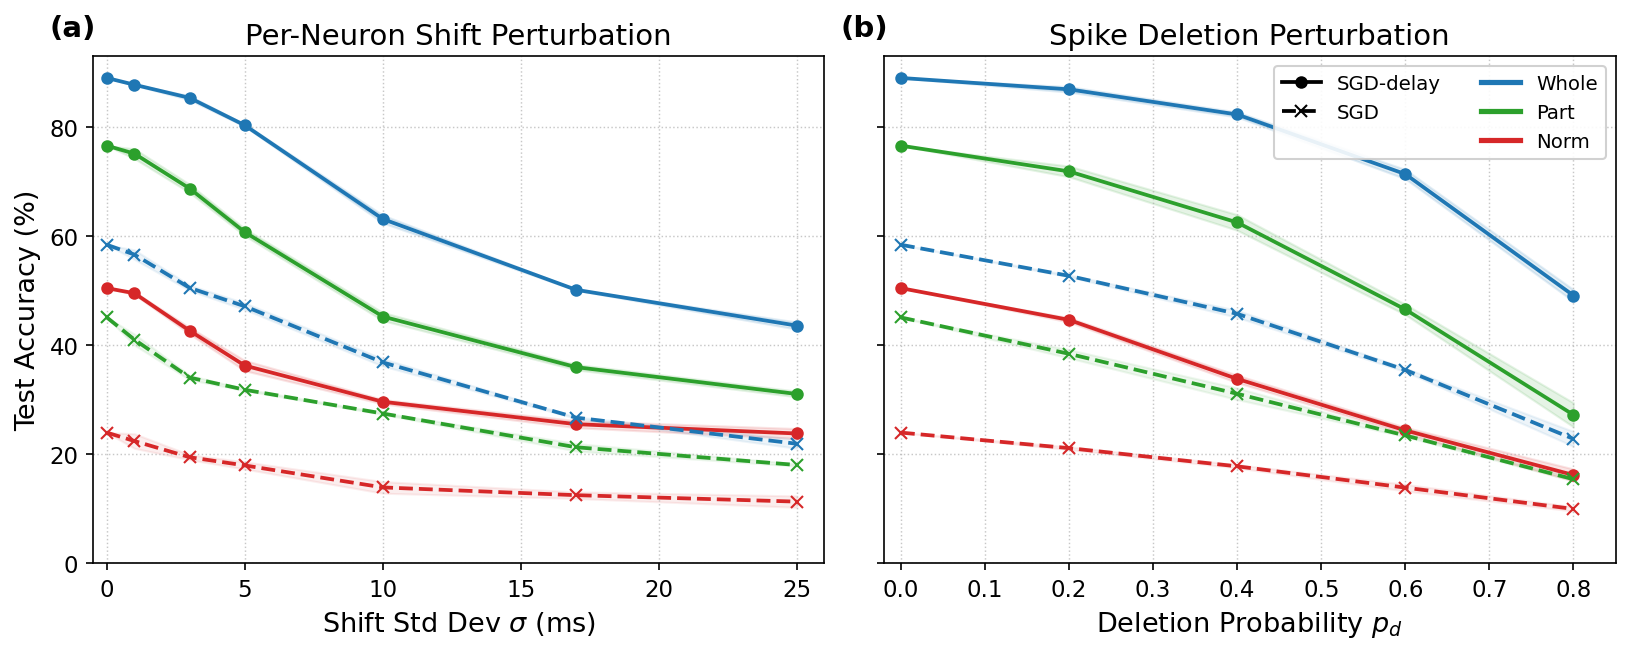

In [4]:
# ---------- Figure 2: shift | deletion ----------
# Block displacement (intra-neuron ISI preserved) vs. outright loss of drive.
fig = draw_paired_figure([
    (shift_sweeps, "Per-Neuron Shift Perturbation",
     r"Shift Std Dev $\sigma$ (ms)", (-0.5, 26)),
    (deletion_sweeps, "Spike Deletion Perturbation",
     r"Deletion Probability $p_d$", (-0.02, 0.85)),
])
#fig.savefig("shift_deletion_2ndLayer_results.png", dpi=150, bbox_inches="tight")
plt.show()

# Phase 4: Time Reversal at the 2nd Hidden Layer

A single model trained on the clean SHD dataset is evaluated under two
conditions at each 2nd-hidden perturbation level $f$ (train-once / eval-all):

- **No reversal** (baseline, dashed × ): a fraction $f$ of each neuron's
  2nd-hidden spikes is relocated to random empty time bins, preserving spike
  count. This is the same relocation probe as Figure 1(a).
- **With reversal** (solid ●): in addition to the $f$-perturbation, each
  sample's 2nd-hidden spike trains are time-reversed within the sample-wide
  active window. This preserves spike count, per-neuron rate, intra-neuron
  ISI, and cross-neuron coincidence — only causal temporal order is flipped.

Comparing the two reveals how much downstream layers rely on causal temporal
order in the 2nd-hidden representation. Sweep: $f$ = 0.0 → 1.0. Because
reversal leaves every other property of the code intact, it gets a figure of
its own rather than being paired with a destructive manipulation.

## 4A: 2nd Hidden-Layer Time Reversal

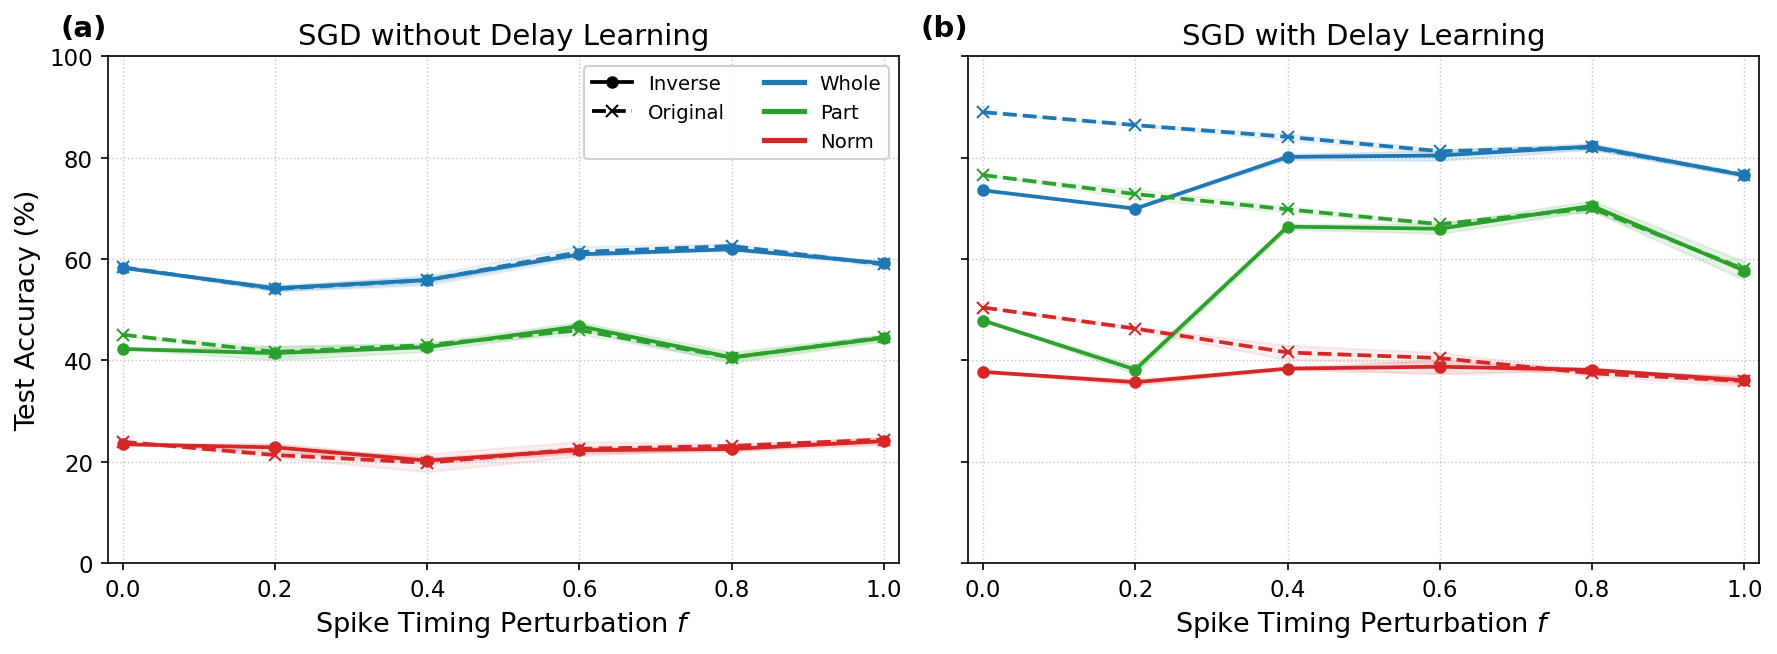

In [5]:
INVERSE_LOG = CODE_PERTURBATION_DIR / "inverse/log"

INVERSE_FILES = {
    ("Whole", True):  INVERSE_LOG / "shd_2ndLayer_whole_delay_hidden2_reversal_sweep_results.json",
    ("Whole", False): INVERSE_LOG / "shd_2ndLayer_whole_nodelay_hidden2_reversal_sweep_results.json",
    ("Part",  True):  INVERSE_LOG / "shd_2ndLayer_part_delay_hidden2_reversal_sweep_results.json",
    ("Part",  False): INVERSE_LOG / "shd_2ndLayer_part_nodelay_hidden2_reversal_sweep_results.json",
    ("Norm",  True):  INVERSE_LOG / "shd_2ndLayer_norm_delay_hidden2_reversal_sweep_results.json",
    ("Norm",  False): INVERSE_LOG / "shd_2ndLayer_norm_nodelay_hidden2_reversal_sweep_results.json",
}


def load_reversal_sweep(
    path: pathlib.Path, condition: str,
) -> tuple[list[float], np.ndarray, np.ndarray]:
    """Load one condition ('no_reversal' or 'reversal') from an inverse JSON."""
    with open(path) as fh:
        raw = json.load(fh)
    cond = raw[condition]
    items = sorted(((float(k), k) for k in cond), key=lambda p: p[0])
    xs = [p[0] for p in items]
    means = np.array([cond[k]["mean"] for _, k in items]) * 100
    stds  = np.array([cond[k]["std"]  for _, k in items]) * 100
    return xs, means, stds


# ---------- Figure 3: split by delay mode; overlay Inverse vs Original ----------
# Style matches the Beyond Rate paper figure (panel (b)/(c)):
#   Inverse  (== reversal,    solid line + filled circle marker)
#   Original (== no_reversal, dashed line + 'x' marker)
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)

for ax, panel_label, use_delay, panel_title in zip(
    axes,
    "ab",
    [False, True],
    ["SGD without Delay Learning", "SGD with Delay Learning"],
):
    for key in VARIANTS:
        path = INVERSE_FILES[(key, use_delay)]

        # Inverse (reversal) — solid line, filled circle marker
        xs, m, std = load_reversal_sweep(path, "reversal")
        ax.plot(xs, m, "o-", color=COLORS[key], markersize=5, linewidth=1.8)
        ax.fill_between(xs, m - std, m + std, color=COLORS[key], alpha=0.12)

        # Original (no_reversal) — dashed line, 'x' marker
        xs, m, std = load_reversal_sweep(path, "no_reversal")
        ax.plot(xs, m, "x--", color=COLORS[key], markersize=6, linewidth=1.8)
        ax.fill_between(xs, m - std, m + std, color=COLORS[key], alpha=0.08)

    ax.set_title(panel_title)
    ax.set_xlabel(r"Spike Timing Perturbation $f$")
    ax.set_xlim(-0.02, 1.02)
    ax.set_ylim(0, 100)
    ax.grid(True, linestyle=":", linewidth=0.7, alpha=0.7)
    ax.text(-0.06, 1.04, f"({panel_label})", transform=ax.transAxes,
            fontsize=14, fontweight="bold")

axes[0].set_ylabel("Test Accuracy (%)")

# Shared legend, drawn once in the left panel.
axes[0].legend(handles=build_legend_handles("Inverse", "Original"),
               loc="upper right", framealpha=0.9, ncol=2)

fig.tight_layout()
#fig.savefig("inverse_2ndLayer_reversal_results.png", dpi=150, bbox_inches="tight")
plt.show()